<a href="https://colab.research.google.com/github/sruthi-analyst/sruthi-codeboosters-2026/blob/main/Day2/Day_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt #data visualisation library
import warnings                 #errors might come for versions and other things, so we import warnings and then tell the system to ignore them all for smooth functioning of the program
warnings.filterwarnings('ignore')

print("All libraries imported succefully")
print("Pandas version: ", pd.__version__)
print("sqlite3 version: ", sqlite3.version)

All libraries imported succefully
Pandas version:  2.2.2
sqlite3 version:  2.6.0


In [5]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/datasets/student_performance.csv")
print(f"Dataset loaded:\n{df.shape[0]} students, {df.shape[1]} attributes")
print(f"\nColumns:\n{df.columns}")
print("\nFirst 3 rows:")
df.head(3)

Dataset loaded:
30 students, 13 attributes

Columns:
Index(['student_id', 'name', 'age', 'gender', 'department', 'semester',
       'math_score', 'science_score', 'english_score', 'programming_score',
       'attendance_percentage', 'city', 'admission_year'],
      dtype='object')

First 3 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [6]:
conn = sqlite3.connect('College.db') #connection object connecting Python environment to SQLite database file College.db
cursor = conn.cursor()  #to navigate and manipulate individual rows or a database query result

# better way to connect to avoid a connection being open and locked:
# with sqlite3.connect('College.db') as conn:
#     cursor = conn.cursor()
#     cursor.execute("SELECT * FROM students")
#     results = cursor.fetchall()

df.to_sql(
    'students',     #Name of table to creare in the database
    conn,           #Which db connection object to use
    if_exists = 'replace', #Is 'students' tab;e exists, replace it
    index=False     #Do not write DataFrame row numbes as a column
)

cursor.execute("SELECT COUNT(*) FROM students")

count = cursor.fetchone()[0]
print("Database 'college.db' created successfully!")
print(f"Table students has {count} rows")


Database 'college.db' created successfully!
Table students has 30 rows


### Understanding SQL Querries
SELECT name, department FROM students WHERE department = 'Computer Science'

In [7]:
cursor.execute("SELECT name, department FROM students WHERE department = 'Computer Science'")
names = cursor.fetchall()
name_list = [n for n in names]
for n in name_list:
  print(n)

('Aarav Sharma', 'Computer Science')
('Priya Patel', 'Computer Science')
('Arjun Nair', 'Computer Science')
('Divya Singh', 'Computer Science')
('Ananya Das', 'Computer Science')
('Suresh Rao', 'Computer Science')
('Ajay Tiwari', 'Computer Science')
('Swati Kulkarni', 'Computer Science')
('Nisha Kapoor', 'Computer Science')
('Tanvi Mehta', 'Computer Science')
('Amit Bose', 'Computer Science')
('Gaurav Shukla', 'Computer Science')
('Akanksha Yadav', 'Computer Science')


In [8]:
cursor.execute("SELECT name, department, math_score, programming_score FROM students WHERE math_score>=90 AND programming_score>=90 ORDER BY (programming_score+math_score) DESC LIMIT 3")
toppers = cursor.fetchall()

for n in toppers:
  print(n[0]) #if print(n) -> prints as tuples in the format (name, department)

Ananya Das
Tanvi Mehta
Arjun Nair


In [9]:
#helper function
def run_query(sql, description="student"):
  '''
  Runs a SQL query ans returns as a pandas Dataframe.

  Paramters:
  ----------
  sql: str - The SQL query string to execute
  description : str - A label to print above results

  Returns:
  ---------
  Pandas Dataframe containing the query results
  '''
  if description:
    print(f"\n{'='*55}")
    print(f"{description}")
    print(f"{'='*55}")

  result=pd.read_sql_query(sql, conn)
  print(result.to_string(index=False))
  return result

print("Helper function 'run_query' defined successfully")
print("Usage: run_query(sql_string, description_label)")

Helper function 'run_query' defined successfully
Usage: run_query(sql_string, description_label)


In [10]:
query1 = "SELECT student_id, name, department, math_score, attendance_percentage FROM students LIMIT(10)"
result = run_query(query1, "Query1: First 10 students (SELCT+LIMIT)")

query2 = "SELECT name, department, math_score FROM students ORDER BY math_score DESC LIMIT 5"
result2 = run_query(query2, "Query2: Top 5 Math Scorers (ORDER BY DESC + LIMIT)")

query3 = "SELECT name, math_score, science_score, programming_score, attendance_percentage FROM students WHERE department = 'Computer Science' ORDER BY programming_score"
result3 = run_query(query3, "Query3: Computer Science Students (WHERE filter)")

query4 = "SELECT name, department, attendance_percentage FROM students WHERE department != 'Civil' AND attendance_percentage>90 ORDER BY attendance_percentage DESC"
result4 = run_query(query4, "Query4: High Attendance (>90%) Ecluding Civil Dept")

query5 = "SELECT name, department, attendance_percentage FROM students WHERE attendance_percentage>93 AND department != 'Mechanical' ORDER BY attendance_percentage DESC LIMIT 3"
result5 = run_query(query5, "Query5: High Attendance (Top3) (>90%) Ecluding Mechanical Dept")


Query1: First 10 students (SELCT+LIMIT)
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98

Query2: Top 5 Math Scorers (ORDER BY DESC + LIMIT)
          name       department  math_score
    Ananya Das C

Case sensitivity: if table name is 'Departments' and query mensions 'departments' -> error
case sensitive!

In [11]:
result6 = run_query("SELECT name FROM students WHERE name BETWEEN 'A' AND 'F'", "Query6: Students names BETWEEN A and F")


Query6: Students names BETWEEN A and F
          name
  Aarav Sharma
    Arjun Nair
   Divya Singh
    Ananya Das
   Ajay Tiwari
Deepak Chauhan
     Amit Bose
Akanksha Yadav



###SQL Aggregate Functions
> COUNT(*)

> SUM(col)

> AVG()

>






>GROUP BY: "Divides the rows into groups based on a column, then applies an aggregate function to each group "

>AS: gives the resulting column or value a relatable name - called alias

In [12]:
query7 = """ SELECT department, COUNT(*) AS num_students,
              ROUND(AVG(math_score), 2) AS avg_math,
              ROUND(AVG(science_score), 2) AS avg_science,
              ROUND(AVG(programming_score), 2) AS avg_programming,
              ROUND(AVG(attendance_percentage), 2) AS avg_attendance
              FROM students
              GROUP BY department
              ORDER BY avg_math DESC
              """
result7 = run_query(query7, "Query7: Average Scores by Group")


Query7: Average Scores by Group
      department  num_students  avg_math  avg_science  avg_programming  avg_attendance
Computer Science            13     85.62        84.46            89.23           90.69
      Mechanical             6     71.00        76.50            49.33           83.50
     Electronics             6     71.00        74.17            61.50           80.33
           Civil             5     63.40        66.60            40.60           74.60


###HAVING

In [13]:
query8 = """ SELECT department,
              ROUND(AVG(math_score), 2) AS avg_math,
              COUNT(*) AS students
              FROM students
              GROUP BY department
              HAVING avg_math > 70
              """
# Filtering before Grouping -> WHERE CLAUSE
# Filtering after Grouping -> HAVING CLAUSE
result8 = run_query(query8, "Query8: Average Math Scores >70")


Query8: Average Math Scores >70
      department  avg_math  students
Computer Science     85.62        13
     Electronics     71.00         6
      Mechanical     71.00         6



Query9: Gender-wise Performance Analysis
gender  num_sttudents  avg_math  avg_programming  avg_attendance
Female             15     78.47             70.2           88.53
  Male             15     73.67             65.0           80.47


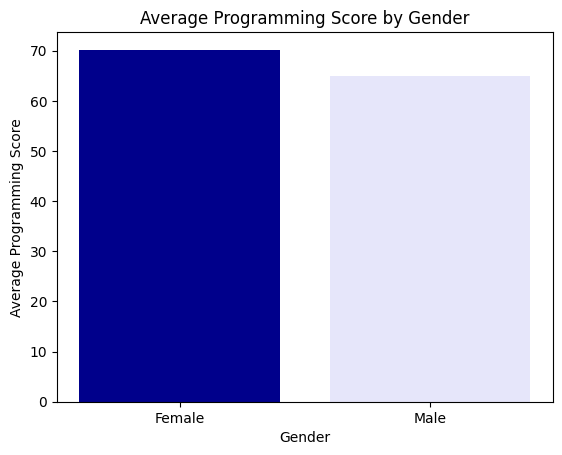

In [14]:
query9 = "SELECT gender, COUNT(*) AS num_sttudents, ROUND(AVG(math_score), 2) AS avg_math, ROUND(AVG(programming_score), 2)  AS avg_programming, ROUND(AVG(attendance_percentage), 2) AS avg_attendance FROM students GROUP BY gender"
result9 = run_query(query9, "Query9: Gender-wise Performance Analysis")

plt.bar(result9['gender'], result9['avg_programming'], color=['darkblue', 'lavender'])
plt.xlabel('Gender')
plt.ylabel('Average Programming Score')
plt.title('Average Programming Score by Gender')
plt.show()

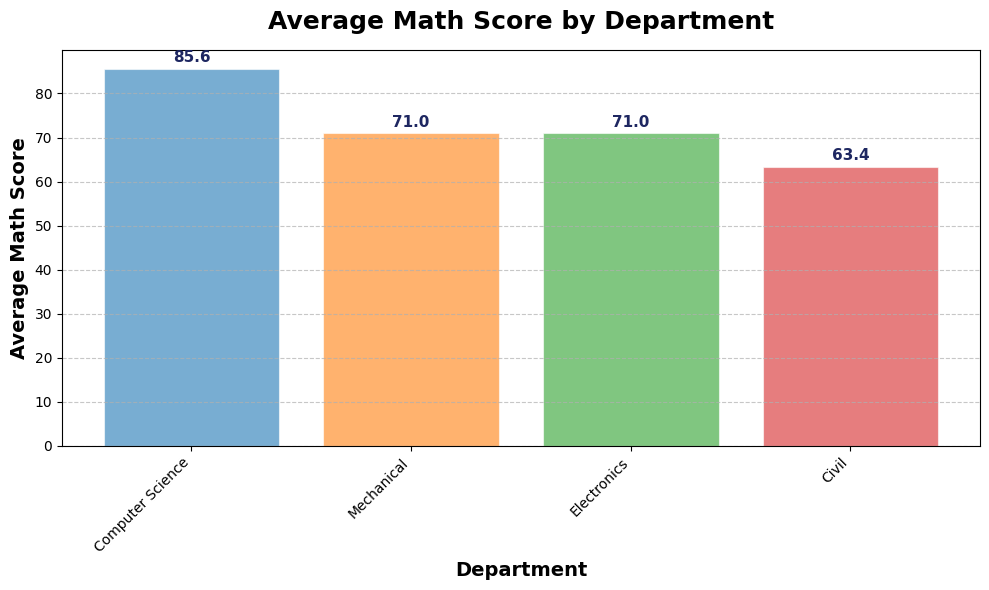

In [15]:
chart1_sql = """
SELECT department,
ROUND(AVG(math_score), 2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
chart1_data = pd.read_sql_query(chart1_sql, conn)

#2: Create the bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']
bars = ax.bar(chart1_data['department'], chart1_data['avg_math'], color=bar_colors, edgecolor='white', linewidth=0.8, alpha=0.6)

for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.8,
      f'{height:.1f}',
      ha='center', va='bottom',
      fontsize=11, fontweight='bold',
      color='#1E2761'
  )

ax.set_title("Average Math Score by Department", fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel("Department", fontsize=14, fontweight='bold')
ax.set_ylabel("Average Math Score", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()